# Part 3 Statistical Analysis
Finding immune cell population relative frequencies between melanoma patients treated with 'miraclib' who responded who treatment vs not treated

Only 'PBMC' samples included. Calculations, filtering, visualization, and testing are performed here

## Analysis Plan
1. Load raw sample metadata and cell counts from 'cell_counts.db'
2. Calculate total cell count and relative frequency for each population in each sample
3. Filter to melanoma, miraclib-treated, PBMC samples with response values of 'yes' or 'no'
4. Visualize responder vs non responder with boxplots
5. Test responder vs non responder per population
6. Apply false discovery rate correction across 5 population tests

In [2]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

DB_PATH = Path("cell-count.db")

if not DB_PATH.exists():
    raise FileNotFoundError("Run `python load_data.py` before opening this notebook.")

## Loading Data
Returns raw cell counts plus metadata for filtering. Relative frequencies calculated after loading raw rows into pandas.

In [18]:
query = """
SELECT
    samples.sample_id AS sample,
    subjects.indication,
    samples.treatment,
    subjects.gender,
    samples.sample_type,
    samples.response,
    samples.time_from_treatment_start,
    populations.population_name AS population,
    counts.cell_count AS count
FROM cell_counts AS counts
INNER JOIN samples
    ON samples.sample_id = counts.sample_id
INNER JOIN subjects
    ON subjects.subject_id = samples.subject_id
INNER JOIN cell_populations AS populations
    ON populations.population_id = counts.population_id;
"""

with sqlite3.connect(DB_PATH) as connection:
    raw_df = pd.read_sql_query(query, connection)

raw_df.head()

,sample,indication,treatment,gender,sample_type,response,time_from_treatment_start,population,count
0,sample00000,melanoma,miraclib,M,PBMC,no,0,b_cell,10908
1,sample00000,melanoma,miraclib,M,PBMC,no,0,cd8_t_cell,24440
2,sample00000,melanoma,miraclib,M,PBMC,no,0,cd4_t_cell,20491
3,sample00000,melanoma,miraclib,M,PBMC,no,0,nk_cell,13864
4,sample00000,melanoma,miraclib,M,PBMC,no,0,monocyte,23511


## Calculate Relative Frequencies
Each sample has 5 rows, one per immune cell population. Total count is sum of 5 populations and relative frequency is population count / sample total

In [9]:
frequency_df = raw_df.copy()
frequency_df["total_count"] = frequency_df.groupby("sample")["count"].transform("sum")
frequency_df["percentage"] = (
    100 * frequency_df["count"] / frequency_df["total_count"]
).round(4)

frequency_df = frequency_df[
    [
        "sample",
        "indication",
        "treatment",
        "sample_type",
        "response",
        "time_from_treatment_start",
        "total_count",
        "population",
        "count",
        "percentage",
    ]
]

frequency_df.head()

,sample,indication,treatment,sample_type,response,time_from_treatment_start,total_count,population,count,percentage
0,sample00000,melanoma,miraclib,PBMC,no,0,93214,b_cell,10908,11.7021
1,sample00000,melanoma,miraclib,PBMC,no,0,93214,cd8_t_cell,24440,26.2192
2,sample00000,melanoma,miraclib,PBMC,no,0,93214,cd4_t_cell,20491,21.9827
3,sample00000,melanoma,miraclib,PBMC,no,0,93214,nk_cell,13864,14.8733
4,sample00000,melanoma,miraclib,PBMC,no,0,93214,monocyte,23511,25.2226


## Filter Analysis Cohert
Filter only melanoma patients getting miraclib, using PBMC samples, and compare response values of 'yes' and 'no'

In [11]:
analysis_df = frequency_df[
    (frequency_df["indication"].str.lower() == "melanoma")
    & (frequency_df["treatment"].str.lower() == "miraclib")
    & (frequency_df["sample_type"].str.upper() == "PBMC")
    & (frequency_df["response"].isin(["yes", "no"]))
].copy()

analysis_df["response_group"] = analysis_df["response"].map(
    {"yes": "Responder", "no": "Non-responder"}
)

analysis_df.shape

(9840, 11)

In [12]:
analysis_df.groupby(["response_group", "population"])["sample"].nunique().unstack(0)

response_group,Non-responder,Responder
population,,
b_cell,975,993
cd4_t_cell,975,993
cd8_t_cell,975,993
monocyte,975,993
nk_cell,975,993


## Boxplots
Boxplot to compare relative frequencies of responder and non responder for each immune cell population

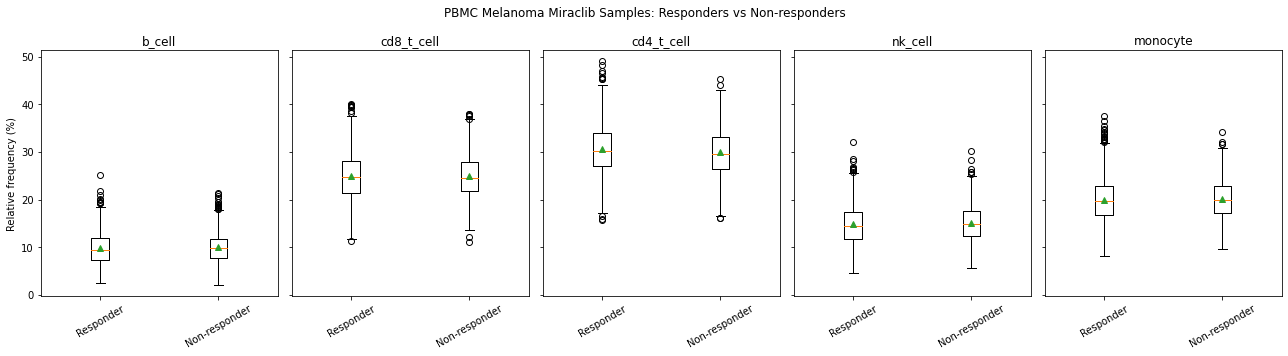

In [13]:
population_order = ["b_cell", "cd8_t_cell", "cd4_t_cell", "nk_cell", "monocyte"]
response_order = ["Responder", "Non-responder"]

fig, axes = plt.subplots(1, len(population_order), figsize=(18, 5), sharey=True)

for ax, population in zip(axes, population_order):
    plot_data = [
        analysis_df.loc[
            (analysis_df["population"] == population)
            & (analysis_df["response_group"] == response_group),
            "percentage",
        ]
        for response_group in response_order
    ]

    ax.boxplot(plot_data, labels=response_order, showmeans=True)
    ax.set_title(population)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Relative frequency (%)")
fig.suptitle("PBMC Melanoma Miraclib Samples: Responders vs Non-responders")
fig.tight_layout()
plt.show()

## Statistical Testing
Comparing responders vs non responders for each cell population

In [14]:
def benjamini_hochberg(p_values):
    p_values = pd.Series(p_values, dtype="float64")
    sorted_p_values = p_values.sort_values()
    ranks = np.arange(1, len(sorted_p_values) + 1)
    adjusted = sorted_p_values * len(sorted_p_values) / ranks
    adjusted = adjusted.iloc[::-1].cummin().iloc[::-1]
    return adjusted.reindex(p_values.index).clip(upper=1.0)


results = []

for population in population_order:
    responder_values = analysis_df.loc[
        (analysis_df["population"] == population)
        & (analysis_df["response_group"] == "Responder"),
        "percentage",
    ]

    non_responder_values = analysis_df.loc[
        (analysis_df["population"] == population)
        & (analysis_df["response_group"] == "Non-responder"),
        "percentage",
    ]

    test = mannwhitneyu(
        responder_values,
        non_responder_values,
        alternative="two-sided",
    )

    results.append(
        {
            "population": population,
            "responder_n": responder_values.size,
            "non_responder_n": non_responder_values.size,
            "responder_median_pct": responder_values.median(),
            "non_responder_median_pct": non_responder_values.median(),
            "median_difference_pct": responder_values.median() - non_responder_values.median(),
            "mann_whitney_u": test.statistic,
            "p_value": test.pvalue,
        }
    )

stats_df = pd.DataFrame(results)
stats_df["fdr_adjusted_p_value"] = benjamini_hochberg(stats_df["p_value"])
stats_df["significant_at_fdr_0_05"] = stats_df["fdr_adjusted_p_value"] < 0.05

stats_df.sort_values("fdr_adjusted_p_value")

,population,responder_n,non_responder_n,responder_median_pct,non_responder_median_pct,median_difference_pct,mann_whitney_u,p_value,fdr_adjusted_p_value,significant_at_fdr_0_05
2,cd4_t_cell,993,975,30.2206,29.6576,0.5630,515277.5,0.013340,0.066699,False
0,b_cell,993,975,9.4323,9.7884,-0.3561,459968.0,0.055672,0.139180,False
3,nk_cell,993,975,14.5093,14.7991,-0.2898,464546.5,0.121060,0.201767,False
4,monocyte,993,975,19.6097,19.9423,-0.3326,466509.0,0.163126,0.203908,False
1,cd8_t_cell,993,975,24.7280,24.6031,0.1249,478175.5,0.639058,0.639058,False


## Significant Population
Finding popoulations with responder vs non responder difference after 0.05 FDR Correction

In [16]:
significant_populations = stats_df[
    stats_df["significant_at_fdr_0_05"]
].sort_values("fdr_adjusted_p_value")
significant_populations

,population,responder_n,non_responder_n,responder_median_pct,non_responder_median_pct,median_difference_pct,mann_whitney_u,p_value,fdr_adjusted_p_value,significant_at_fdr_0_05


## Interpretation Helper
Positive 'median_difference_pct' means population has higher median relative frequency in responders. Negative values mean its higher in non-responders

In [17]:
for row in stats_df.sort_values("fdr_adjusted_p_value").itertuples(index=False):
    direction = "higher in responders" if row.median_difference_pct > 0 else "higher in non-responders"
    significance = "higher in responders" if row.significant_at_fdr_0_05 > 0 else "higher in non-responders"
    print(
        f"{row.population}: {significance}; "
        f"median difference = {row.median_difference_pct:.3f} percentage points "
        f"({direction}); FDR-adjusted p = {row.fdr_adjusted_p_value:.4g}"
    )

cd4_t_cell: higher in non-responders; median difference = 0.563 percentage points (higher in responders); FDR-adjusted p = 0.0667
b_cell: higher in non-responders; median difference = -0.356 percentage points (higher in non-responders); FDR-adjusted p = 0.1392
nk_cell: higher in non-responders; median difference = -0.290 percentage points (higher in non-responders); FDR-adjusted p = 0.2018
monocyte: higher in non-responders; median difference = -0.333 percentage points (higher in non-responders); FDR-adjusted p = 0.2039
cd8_t_cell: higher in non-responders; median difference = 0.125 percentage points (higher in responders); FDR-adjusted p = 0.6391


## Male Melanoma avg b cells at t=0
Considering Melanoma males, what is the average number of B cells for responders at time=0?

In [20]:
melanoma_mal_bcell_responders_time0 = raw_df[
    (raw_df["indication"].str.lower() == "melanoma")
    & (raw_df["response"].str.lower() == "yes")
    & (raw_df["time_from_treatment_start"] == 0)
    & (raw_df["population"] == "b_cell")
    & (raw_df["gender"] == "M")
]

avg_b_cells = melanoma_mal_bcell_responders_time0["count"].mean()
f"{avg_b_cells:.2f}"

'10206.15'